In [1]:
# Import Numpy & PyTorch
import numpy as np
import torch

### create tensors

In [2]:
x = torch.tensor(4.)
w = torch.tensor(5., requires_grad=True)
b = torch.tensor(6., requires_grad=True)

In [3]:
# Print tensors
print(x)
print(w)
print(b)

tensor(4.)
tensor(5., requires_grad=True)
tensor(6., requires_grad=True)


### Equation of a straight line

#### y = w * x + b

##### we can automatically compute the derivative of y w.r.t. the tensors that have requires_grad set to True

In [4]:
# Arithmetic operations
y = w * x + b
print(y)

tensor(26., grad_fn=<AddBackward0>)


#### compute gradients

#####  we can automatically compute the derivative of y w.r.t. the tensors that have requires_grad set to True

In [5]:
y.backward()

In [ ]:
# Display gradients
print('dy/dw:', w.grad) #dy/dw= x
print('dy/db:', b.grad) #dy/db= 1

dy/dw: tensor(4.)
dy/db: tensor(1.)


In [ ]:
####https://www.kaggle.com/aakashns/pytorch-basics-linear-regression-from-scratch
####https://medium.com/dsnet/linear-regression-with-pytorch-3dde91d60b50


#####https://www.kaggle.com/krishanudb/basic-computation-graph-using-pytorch/code
##https://www.kaggle.com/leostep/pytorch-dense-network-for-house-pricing-regression

In [7]:
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


In [8]:
input_size = 1
output_size = 1
num_epochs = 10000
learning_rate = 0.001

In [9]:
x_train = np.array([[3.3], [4.4], [5.5], [6.71], [6.93], [4.168],[9.779], [6.182], [7.59], [2.167], [7.042], [10.791], [5.313], [7.997], [3.1]], dtype=np.float32)

y_train = np.array([[1.7], [2.76], [2.09], [3.19], [1.694], [1.573], [3.366], [2.596], [2.53], [1.221], [2.827], [3.465], [1.65], [2.904], [1.3]], dtype=np.float32)

In [10]:
model = nn.Linear(input_size, output_size)

# Loss Function:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [23]:
for epoch in range(num_epochs):
    inputs = torch.from_numpy(x_train) ## convert numpy to tensor
    targets = torch.from_numpy(y_train)
    outputs = model(inputs)
    loss = criterion(outputs, targets) ## predicted and actual Y
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Print the loss
    print(f"Epoch {epoch + 1}: Loss = {loss.item()}")

Epoch 1: Loss = 12.317523002624512
Epoch 2: Loss = 10.354696273803711
Epoch 3: Loss = 8.716354370117188
Epoch 4: Loss = 7.3488545417785645
Epoch 5: Loss = 6.20741605758667
Epoch 6: Loss = 5.254665851593018
Epoch 7: Loss = 4.459408760070801
Epoch 8: Loss = 3.795605421066284
Epoch 9: Loss = 3.2415244579315186
Epoch 10: Loss = 2.779024839401245
Epoch 11: Loss = 2.3929662704467773
Epoch 12: Loss = 2.0707106590270996
Epoch 13: Loss = 1.801709532737732
Epoch 14: Loss = 1.5771583318710327
Epoch 15: Loss = 1.389708399772644
Epoch 16: Loss = 1.233225703239441
Epoch 17: Loss = 1.102590799331665
Epoch 18: Loss = 0.9935301542282104
Epoch 19: Loss = 0.9024770259857178
Epoch 20: Loss = 0.826454222202301
Epoch 21: Loss = 0.7629769444465637
Epoch 22: Loss = 0.709971010684967
Epoch 23: Loss = 0.6657052636146545
Epoch 24: Loss = 0.6287345886230469
Epoch 25: Loss = 0.597852885723114
Epoch 26: Loss = 0.5720537304878235
Epoch 27: Loss = 0.5504967570304871
Epoch 28: Loss = 0.5324805974960327
Epoch 29: Loss 

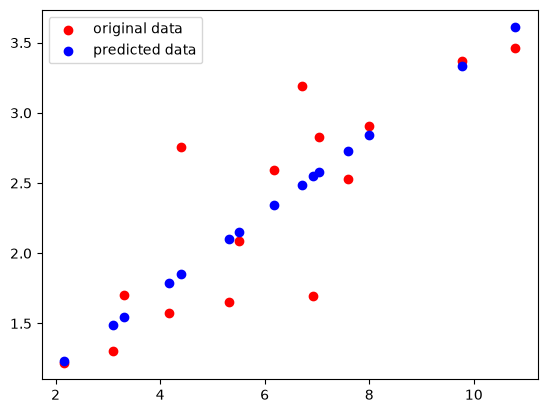

In [ ]:
predicted = model(torch.from_numpy(x_train)).detach().numpy() ## predicted Y

plt.scatter(x_train, y_train, color='red',label='original data')
plt.scatter(x_train, predicted, color='blue', label='predicted data')
plt.legend()
plt.show()

In [11]:
####https://www.kaggle.com/kunal627/titanic-logistic-regression-with-python
####https://www.kaggle.com/kiranscaria/titanic-pytorch
####https://www.kaggle.com/dpamgautam/pytorch-linear-regression
####https://bennydai.files.wordpress.com/2018/02/iris-example-pytorch-implementation.pdf

In [12]:
##https://www.kaggle.com/dpamgautam/linear-and-logistic-regression-using-pytorch

In [13]:
#### ols--> house price: https://towardsdatascience.com/create-a-model-to-predict-house-prices-using-python-d34fe8fad88f

In [14]:
import pandas as pd

In [15]:
import numpy as np

In [18]:
dataset = pd.read_csv('titanic_raw.csv')
X_test = pd.read_csv('titanic_test.csv')

In [19]:
dataset_title = [i.split(',')[1].split('.')[0].strip() for i in dataset['Name']]
dataset['Title'] = pd.Series(dataset_title)
dataset['Title'].value_counts()
dataset['Title'] = dataset['Title'].replace(['Lady', 'the Countess', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona', 'Ms', 'Mme', 'Mlle'], 'Rare')

dataset_title = [i.split(',')[1].split('.')[0].strip() for i in X_test['Name']]
X_test['Title'] = pd.Series(dataset_title)
X_test['Title'].value_counts()
X_test['Title'] = X_test['Title'].replace(['Lady', 'the Countess', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona', 'Ms', 'Mme', 'Mlle'], 'Rare')

dataset['FamilyS'] = dataset['SibSp'] + dataset['Parch'] + 1
X_test['FamilyS'] = X_test['SibSp'] + X_test['Parch'] + 1

In [20]:
def family(x):
    if x < 2:
        return 'Single'
    elif x == 2:
        return 'Couple'
    elif x <= 4:
        return 'InterM'
    else:
        return 'Large'
    
dataset['FamilyS'] = dataset['FamilyS'].apply(family)
X_test['FamilyS'] = X_test['FamilyS'].apply(family)

In [21]:
dataset['Embarked'].fillna(dataset['Embarked'].mode()[0], inplace=True)
X_test['Embarked'].fillna(X_test['Embarked'].mode()[0], inplace=True)
dataset['Age'].fillna(dataset['Age'].median(), inplace=True)
X_test['Age'].fillna(X_test['Age'].median(), inplace=True)
X_test['Fare'].fillna(X_test['Fare'].median(), inplace=True)

/var/folders/8t/4ttt_tc53hs994xcrmjg2p880000gn/T/ipykernel_53898/3076494000.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataset['Embarked'].fillna(dataset['Embarked'].mode()[0], inplace=True)
/var/folders/8t/4ttt_tc53hs994xcrmjg2p880000gn/T/ipykernel_53898/3076494000.py:2: ChainedAssignmentError: A value is being set on a cop

0        7.8292
1        7.0000
2        9.6875
3        8.6625
4       12.2875
         ...   
413      8.0500
414    108.9000
415      7.2500
416      8.0500
417     22.3583
Name: Fare, Length: 418, dtype: float64

### see data type

In [22]:
titanic.dtypes ## see data type

NameError: name 'titanic' is not defined

### remove columns

### Do we have NAs?

In [6]:
print('Columns with null values:\n', titanic.isnull().sum())


Columns with null values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
#### make a copy of the data frame

t1 = titanic.copy(deep = True)


In [8]:
t_drop=t1.dropna()

In [9]:
print('Columns with null values:\n', t_drop.isnull().sum())


Columns with null values:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [ ]:
t2 = titanic.copy(deep = True) ##another copy